In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("covid_data.csv")

In [3]:
df.head()

,iso_code,continent,location,date,total_cases,new_cases,new_cases_smoothed,total_deaths,new_deaths,new_deaths_smoothed,...,male_smokers,handwashing_facilities,hospital_beds_per_thousand,life_expectancy,human_development_index,population,excess_mortality_cumulative_absolute,excess_mortality_cumulative,excess_mortality,excess_mortality_cumulative_per_million
0,AFG,Asia,Afghanistan,2020-01-03,NaN,0.0,NaN,NaN,0.0,NaN,...,NaN,37.746,0.5,64.83,0.511,41128772.0,NaN,NaN,NaN,NaN
1,AFG,Asia,Afghanistan,2020-01-04,NaN,0.0,NaN,NaN,0.0,NaN,...,NaN,37.746,0.5,64.83,0.511,41128772.0,NaN,NaN,NaN,NaN
2,AFG,Asia,Afghanistan,2020-01-05,NaN,0.0,NaN,NaN,0.0,NaN,...,NaN,37.746,0.5,64.83,0.511,41128772.0,NaN,NaN,NaN,NaN
3,AFG,Asia,Afghanistan,2020-01-06,NaN,0.0,NaN,NaN,0.0,NaN,...,NaN,37.746,0.5,64.83,0.511,41128772.0,NaN,NaN,NaN,NaN
4,AFG,Asia,Afghanistan,2020-01-07,NaN,0.0,NaN,NaN,0.0,NaN,...,NaN,37.746,0.5,64.83,0.511,41128772.0,NaN,NaN,NaN,NaN


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 350085 entries, 0 to 350084
Data columns (total 67 columns):
 #   Column                                      Non-Null Count   Dtype  
---  ------                                      --------------   -----  
 0   iso_code                                    350085 non-null  str    
 1   continent                                   333420 non-null  str    
 2   location                                    350085 non-null  str    
 3   date                                        350085 non-null  str    
 4   total_cases                                 312088 non-null  float64
 5   new_cases                                   340457 non-null  float64
 6   new_cases_smoothed                          339198 non-null  float64
 7   total_deaths                                290501 non-null  float64
 8   new_deaths                                  340511 non-null  float64
 9   new_deaths_smoothed                         339281 non-null  float64
 10  total_c

In [5]:
df.shape

(350085, 67)

In [6]:
df.describe()

,total_cases,new_cases,new_cases_smoothed,total_deaths,new_deaths,new_deaths_smoothed,total_cases_per_million,new_cases_per_million,new_cases_smoothed_per_million,total_deaths_per_million,...,male_smokers,handwashing_facilities,hospital_beds_per_thousand,life_expectancy,human_development_index,population,excess_mortality_cumulative_absolute,excess_mortality_cumulative,excess_mortality,excess_mortality_cumulative_per_million
count,3.120880e+05,3.404570e+05,3.391980e+05,2.905010e+05,340511.000000,339281.000000,312088.000000,340457.000000,339198.000000,290501.000000,...,200889.000000,132973.000000,239669.000000,322072.000000,263138.000000,3.500850e+05,1.218400e+04,12184.000000,12184.000000,12184.000000
mean,6.683354e+06,9.601634e+03,9.637066e+03,8.602180e+04,85.511055,85.817071,101749.851259,145.163814,145.696924,872.289356,...,32.909483,50.789962,3.097245,73.713631,0.722464,1.284633e+08,5.281637e+04,9.738648,11.345256,1669.025575
std,4.068903e+07,1.102769e+05,9.447784e+04,4.398873e+05,613.687971,559.130004,151265.689121,1163.714678,599.957847,1100.189784,...,13.573767,31.956100,2.548327,7.395220,0.148976,6.607694e+08,1.492195e+05,12.304441,25.181297,1938.556228
min,1.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,7.700000,1.188000,0.100000,53.280000,0.394000,4.700000e+01,-3.772610e+04,-44.230000,-95.920000,-2752.924800
25%,8.090000e+03,0.000000e+00,2.860000e-01,1.270000e+02,0.000000,0.000000,2595.577500,0.000000,0.044000,60.606000,...,22.600000,20.859000,1.300000,69.590000,0.602000,4.490020e+05,1.202250e+02,1.400000,-1.600000,72.395046
50%,7.020500e+04,2.000000e+00,2.485700e+01,1.328000e+03,0.000000,0.143000,28307.659000,0.128000,6.517000,377.169000,...,33.100000,49.839000,2.500000,75.050000,0.740000,5.882259e+06,5.885850e+03,8.075000,5.720000,1105.404700
75%,7.409558e+05,2.640000e+02,4.978570e+02,1.192200e+04,3.000000,5.143000,133506.244000,35.466000,82.411000,1365.925000,...,41.300000,82.502000,4.200000,79.460000,0.829000,2.830170e+07,3.742344e+04,15.360000,16.302500,2740.130200
max,7.714071e+08,8.401961e+06,6.402036e+06,6.972139e+06,27939.000000,14822.000000,737554.506000,228872.025000,37241.781000,6511.209000,...,78.100000,100.000000,13.800000,86.750000,0.957000,7.975105e+09,1.289776e+06,76.620000,377.630000,10292.916000


In [7]:
df.isnull().sum()

iso_code                                        0
continent                                   16665
location                                        0
date                                            0
total_cases                                 37997
                                            ...  
population                                      0
excess_mortality_cumulative_absolute       337901
excess_mortality_cumulative                337901
excess_mortality                           337901
excess_mortality_cumulative_per_million    337901
Length: 67, dtype: int64

In [8]:
df = df[[
    "location",
    "date",
    "total_cases",
    "new_cases",
    "total_deaths",
    "population"
]]

In [9]:
df.head()

,location,date,total_cases,new_cases,total_deaths,population
0,Afghanistan,2020-01-03,NaN,0.0,NaN,41128772.0
1,Afghanistan,2020-01-04,NaN,0.0,NaN,41128772.0
2,Afghanistan,2020-01-05,NaN,0.0,NaN,41128772.0
3,Afghanistan,2020-01-06,NaN,0.0,NaN,41128772.0
4,Afghanistan,2020-01-07,NaN,0.0,NaN,41128772.0


In [10]:
df.dtypes

location            str
date                str
total_cases     float64
new_cases       float64
total_deaths    float64
population      float64
dtype: object

In [11]:
df["date"] = pd.to_datetime(df["date"])

In [12]:
df.dtypes

location                   str
date            datetime64[us]
total_cases            float64
new_cases              float64
total_deaths           float64
population             float64
dtype: object

In [13]:
df["total_cases"] = df["total_cases"].fillna(0)
df["new_cases"] = df["new_cases"].fillna(0)
df["total_deaths"] = df["total_deaths"].fillna(0)

In [14]:
df.isnull().sum()

location        0
date            0
total_cases     0
new_cases       0
total_deaths    0
population      0
dtype: int64

In [15]:
print("Duplicates before:", df.duplicated().sum())

Duplicates before: 0


In [16]:
df.drop_duplicates(inplace=True)

In [17]:
print("Duplicates after:", df.duplicated().sum())

Duplicates after: 0


In [18]:
df.to_csv("cleaned_covid_data.csv", index=False)

In [19]:
df.head()

,location,date,total_cases,new_cases,total_deaths,population
0,Afghanistan,2020-01-03,0.0,0.0,0.0,41128772.0
1,Afghanistan,2020-01-04,0.0,0.0,0.0,41128772.0
2,Afghanistan,2020-01-05,0.0,0.0,0.0,41128772.0
3,Afghanistan,2020-01-06,0.0,0.0,0.0,41128772.0
4,Afghanistan,2020-01-07,0.0,0.0,0.0,41128772.0


In [20]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 350085 entries, 0 to 350084
Data columns (total 6 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   location      350085 non-null  str           
 1   date          350085 non-null  datetime64[us]
 2   total_cases   350085 non-null  float64       
 3   new_cases     350085 non-null  float64       
 4   total_deaths  350085 non-null  float64       
 5   population    350085 non-null  float64       
dtypes: datetime64[us](1), float64(4), str(1)
memory usage: 16.0 MB


In [21]:
country_cases = df.groupby("location")["total_cases"].max()

country_cases.head()

location
Afghanistan         226816.0
Africa            13113845.0
Albania             334090.0
Algeria             271945.0
American Samoa        8359.0
Name: total_cases, dtype: float64

In [22]:
country_deaths = df.groupby("location")["total_deaths"].max()

country_deaths.head()

location
Afghanistan         7952.0
Africa            259023.0
Albania             3604.0
Algeria             6881.0
American Samoa        34.0
Name: total_deaths, dtype: float64

In [23]:
top10 = country_cases.sort_values(ascending=False).head(10)

top10

location
World                  771407061.0
High income            425988398.0
Asia                   300681974.0
Europe                 249783754.0
Upper middle income    244463792.0
European Union         184210531.0
North America          124492151.0
United States          103436829.0
China                   99315684.0
Lower middle income     97458491.0
Name: total_cases, dtype: float64

In [24]:
top10_deaths = country_deaths.sort_values(ascending=False).head(10)

top10_deaths

location
World                  6972139.0
High income            2914272.0
Upper middle income    2666760.0
Europe                 2079783.0
Asia                   1633880.0
North America          1613118.0
South America          1356419.0
Lower middle income    1339160.0
European Union         1245398.0
United States          1136920.0
Name: total_deaths, dtype: float64

In [25]:
pakistan = df[df["location"] == "Pakistan"]

pakistan.head()

,location,date,total_cases,new_cases,total_deaths,population
235403,Pakistan,2020-01-03,0.0,0.0,0.0,235824864.0
235404,Pakistan,2020-01-04,0.0,0.0,0.0,235824864.0
235405,Pakistan,2020-01-05,0.0,0.0,0.0,235824864.0
235406,Pakistan,2020-01-06,0.0,0.0,0.0,235824864.0
235407,Pakistan,2020-01-07,0.0,0.0,0.0,235824864.0


In [26]:
pakistan.shape

(1385, 6)

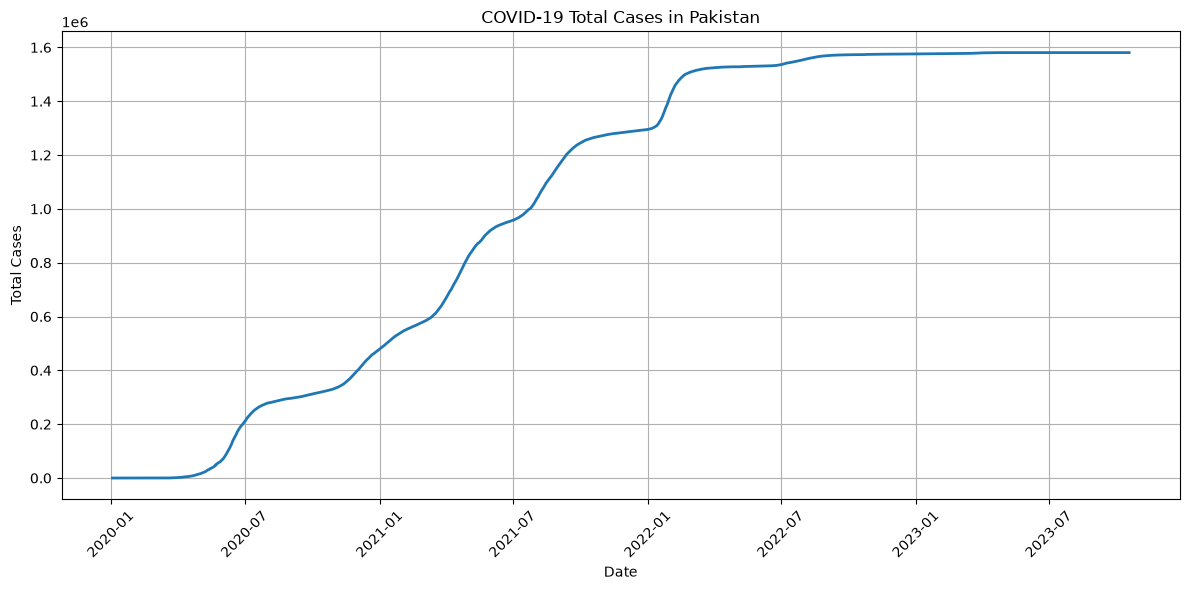

In [27]:
plt.figure(figsize=(12,6))

plt.plot(
    pakistan["date"],
    pakistan["total_cases"],
    linewidth=2
)

plt.title("COVID-19 Total Cases in Pakistan")
plt.xlabel("Date")
plt.ylabel("Total Cases")

plt.xticks(rotation=45)

plt.grid(True)

plt.tight_layout()

plt.savefig("charts/line_cases.png")

plt.show()

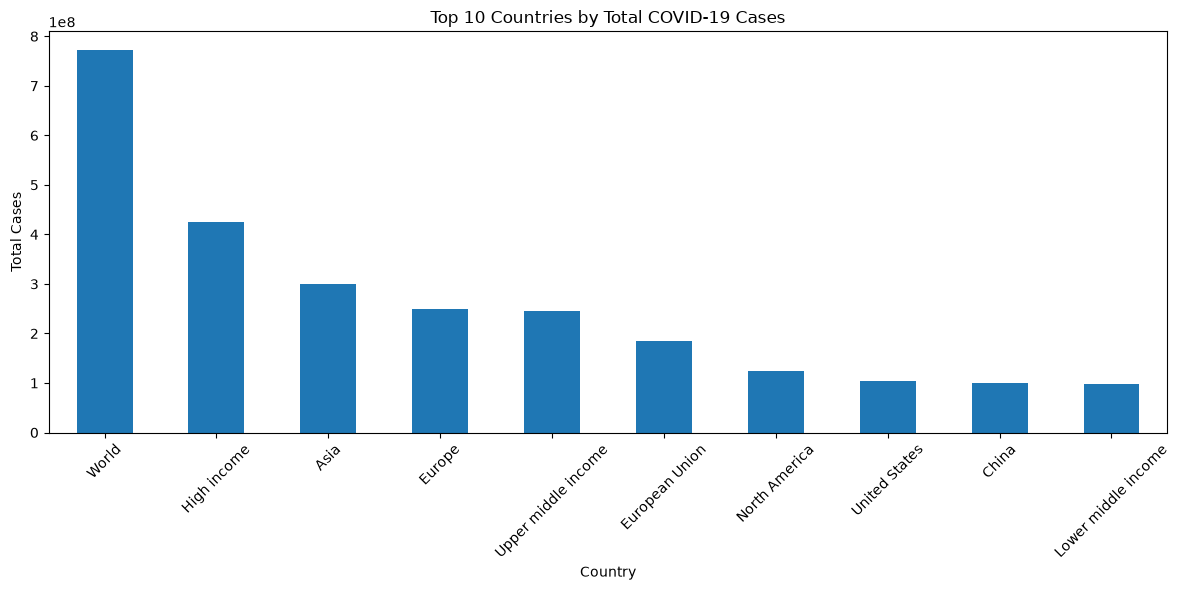

In [28]:
plt.figure(figsize=(12,6))

top10.plot(kind="bar")

plt.title("Top 10 Countries by Total COVID-19 Cases")
plt.xlabel("Country")
plt.ylabel("Total Cases")

plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig("charts/top10_cases.png")

plt.show()

In [29]:
country_summary = pd.DataFrame({
    "Total Cases": country_cases,
    "Total Deaths": country_deaths
})

country_summary.head()

,Total Cases,Total Deaths
location,,
Afghanistan,226816.0,7952.0
Africa,13113845.0,259023.0
Albania,334090.0,3604.0
Algeria,271945.0,6881.0
American Samoa,8359.0,34.0


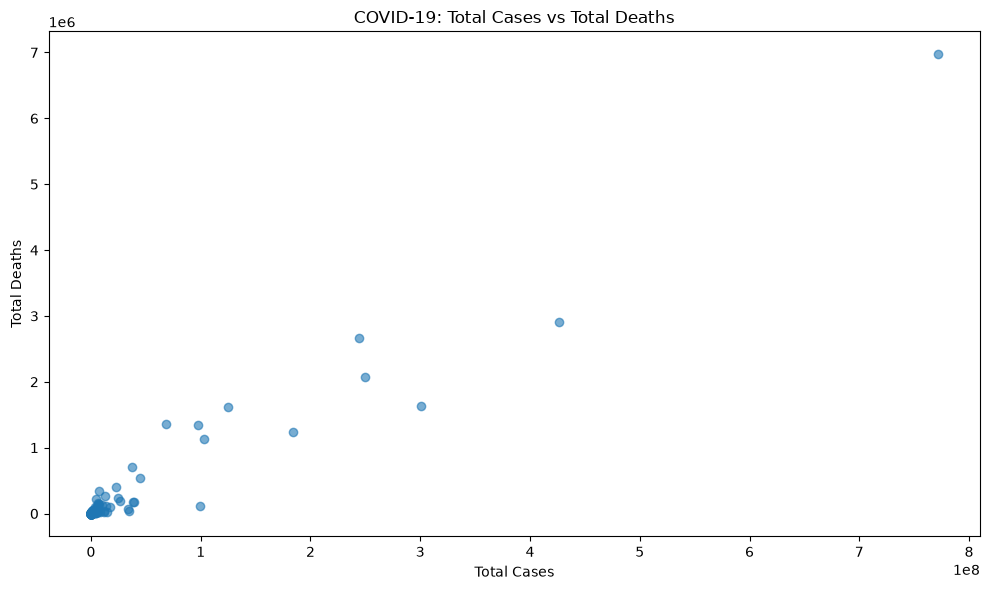

In [30]:
plt.figure(figsize=(10,6))

plt.scatter(
    country_summary["Total Cases"],
    country_summary["Total Deaths"],
    alpha=0.6
)

plt.title("COVID-19: Total Cases vs Total Deaths")
plt.xlabel("Total Cases")
plt.ylabel("Total Deaths")

plt.tight_layout()

plt.savefig("charts/cases_vs_deaths.png")

plt.show()

In [31]:
df.to_csv("result_analysis_output.csv", index=False)

print("Dataset saved successfully!")

Dataset saved successfully!
